In [1]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

In [2]:
df_beyondblue=pd.read_csv("beyondblue_merged_unique.csv")
df_beyondblue

,keyword,post_content_preview,thread_url,post_date,comments,num_comments
0,anxiety,Hi my name is Michelle and I have hadAnxietymy...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎23-05-2025,"[""Dear Michelle ~Welcome here to the Support F...",2
1,anxiety,"Hi, I’ve suffered on and off fromanxietyover...",https://forums.beyondblue.org.au/t5/welcome-an...,‎28-05-2025,['Hello new member and welcome to the forum.Pl...,4
2,anxiety,taking breaks and ambient noise doesn't seem t...,https://forums.beyondblue.org.au/t5/staying-we...,Unknown,"[""will make this brief as its a contextual pos...",9
3,anxiety,"I have had chronicanxietysince 2016, but I hav...",https://forums.beyondblue.org.au/t5/anxiety/an...,‎06-01-2025,"['Dear Guest-65543263,I can very much relate t...",9
4,anxiety,Hello I struggle with very badanxietyand panic...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-03-2025,"['Hello any advice please would help', ""Hi don...",4
...,...,...,...,...,...,...
18393,staying well,...an I help my wife? Can I help me? Can I hel...,https://forums.beyondblue.org.au/t5/long-term-...,‎03-06-2016,"Hi, Unfortunately Im not experienced enough to...",9
18394,staying well,"Hey everyone, hope someone can give me an outs...",https://forums.beyondblue.org.au/t5/young-peop...,‎09-01-2018,"Hi Spl spl, I cannot say I have come across th...",9
18395,staying well,...ost of my time has just been spent watching...,https://forums.beyondblue.org.au/t5/young-peop...,‎31-03-2017,"Dear Nxrza, Welcom to the Forum, I think there...",9
18396,staying well,"As the saying goes ""life begins at 60"" \n Sinc...",https://forums.beyondblue.org.au/t5/staying-we...,‎08-11-2017,"hi Meercat , absolutely, for me it has greatly...",9


In [3]:
df_beyondblue.isnull().sum()

keyword                  0
post_content_preview     0
thread_url               0
post_date               45
comments                19
num_comments             0
dtype: int64

In [4]:
df_beyondblue.describe()

,num_comments
count,18398.000000
mean,5.075171
std,2.920473
min,0.000000
25%,2.000000
50%,5.000000
75%,9.000000
max,9.000000


In [5]:
import pandas as pd
import re
import string
import ast
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as sklearn_stopwords

custom_stopwords = {
    "hi", "hello", "im", "ive", "ve", "go", "thing", "know", "time", "year","dont",
    "people", "work", "start", "day", "get", "say", "come", "make", "m", "w", "s", "t", "feel", "ago","bot","performed",
    "like", "just", "want", "see","action","discord","reddit","post","comment","reply","user","users","server","automatically","contact","message","moderators","team","support","help","issue","problem","question","answer","solution","feedback","discussion",
    "topic","thread","conversation","chat","discussion","forum","platform","community","group","channel","subreddit","sub","link","url","website","web","app","application","platforms","automated"}
combined_stopwords = sklearn_stopwords.union(custom_stopwords)

def clean_text(text):
    """Lowercase, remove URLs, punctuation, extra whitespace."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\n", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.lower()
    return text.strip()

def basic_clean(text):
    """Lowercase, remove non-alphabetic characters and collapse whitespace."""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def remove_stopwords(text):
    """Remove stopwords including custom ones."""
    tokens = text.split()
    filtered = [tok for tok in tokens if tok not in combined_stopwords]
    return " ".join(filtered)

def final_clean(text):
    """Apply full cleaning pipeline."""
    text = clean_text(text)
    text = basic_clean(text)
    text = remove_stopwords(text)
    return text

# Clean the 'post_content_preview' column

# For post text
df_beyondblue['post_content_preview_clean'] = df_beyondblue['post_content_preview'].apply(final_clean)

def safe_literal_eval(x):
    if not isinstance(x, str):
        return ""
    try:
        val = ast.literal_eval(x)
        if isinstance(val, list):
            return " ".join(val)
        else:
            return str(val)
    except (ValueError, SyntaxError):
        return x  # fallback: use the string as-is

df_beyondblue['comments_clean'] = df_beyondblue['comments'].apply(lambda x: final_clean(safe_literal_eval(x)))
# Optional: Add basic length columns
df_beyondblue['post_length'] = df_beyondblue['post_content_preview_clean'].apply(len)
df_beyondblue['num_comments_length'] = df_beyondblue['comments_clean'].apply(lambda x: len(x.split()))


<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal


In [6]:
unknown_count = (df_beyondblue['post_date'] == 'Unknown').sum()
print(f"Number of posts with unknown date: {unknown_count}")

Number of posts with unknown date: 71


In [7]:
# When filtering, use .copy()
df_beyondblue = df_beyondblue[df_beyondblue['post_date'] != 'Unknown'].copy()

In [8]:
# Remove rows with null values in 'post_date' and 'comments'
df_beyondblue = df_beyondblue.dropna(subset=['post_date', 'comments']).copy()

In [9]:
df_beyondblue.dtypes

keyword                       object
post_content_preview          object
thread_url                    object
post_date                     object
comments                      object
num_comments                   int64
post_content_preview_clean    object
comments_clean                object
post_length                    int64
num_comments_length            int64
dtype: object

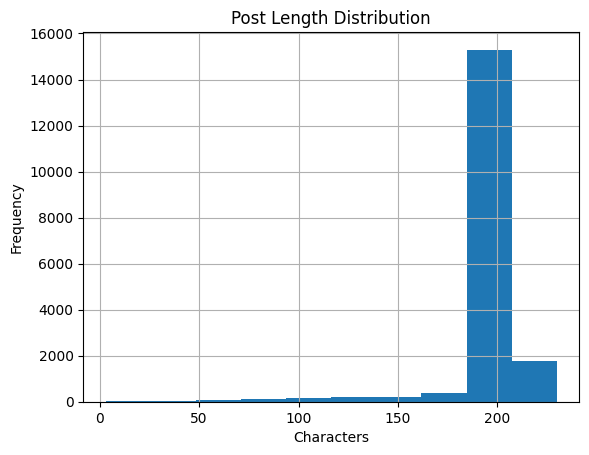

In [10]:
df_beyondblue['post_length'] = df_beyondblue['post_content_preview'].str.len()

df_beyondblue['post_length'].hist(bins=10)
plt.title("Post Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


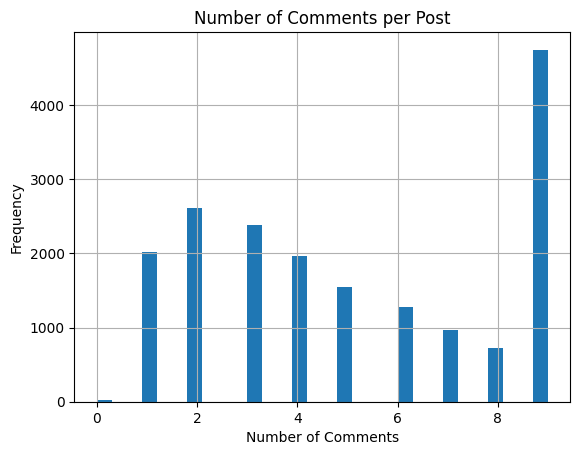

In [11]:
df_beyondblue['num_comments'].hist(bins=30)
plt.title("Number of Comments per Post")
plt.xlabel("Number of Comments")
plt.ylabel("Frequency")
plt.show()


/var/folders/x7/xrth4_p955x331lrb98xvffh0000gn/T/ipykernel_30655/3706255347.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


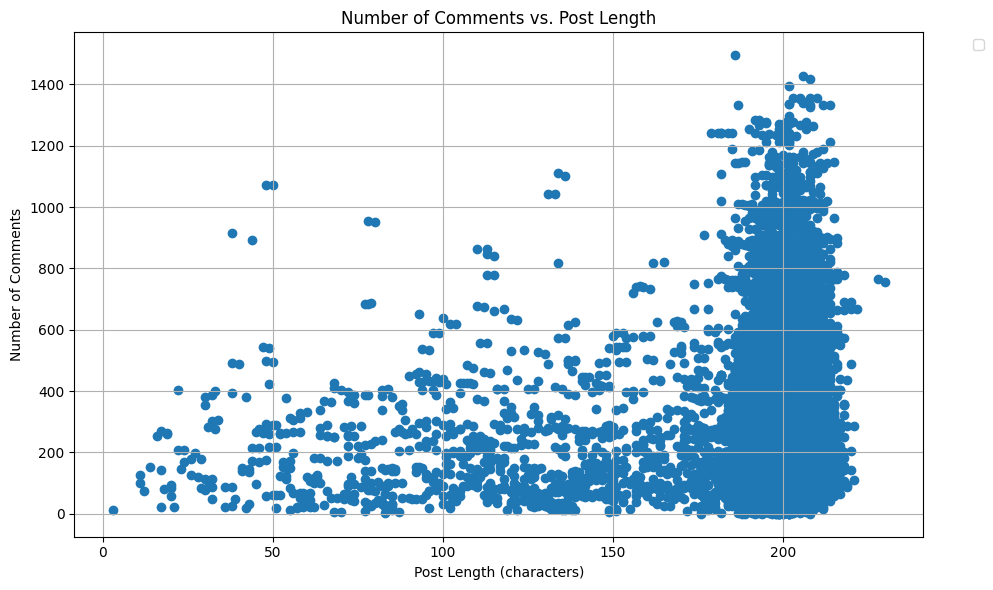

In [12]:
# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df_beyondblue['post_length'], df_beyondblue['num_comments_length'])

plt.title('Number of Comments vs. Post Length')
plt.xlabel('Post Length (characters)')
plt.ylabel('Number of Comments')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.show()



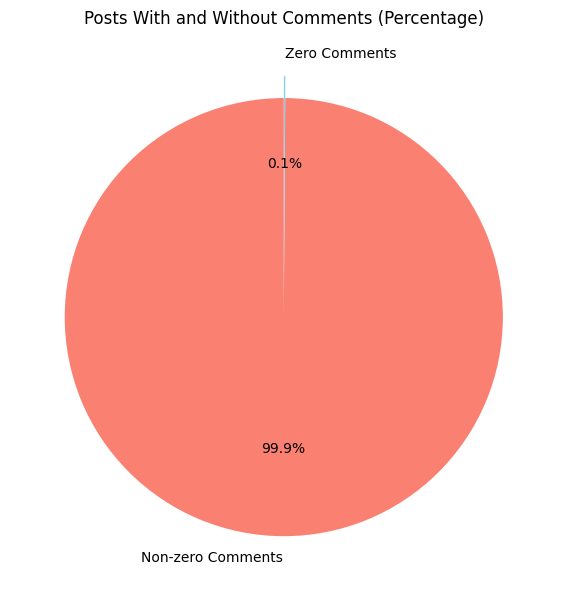

In [13]:
# Pie chart for posts with zero vs. non-zero comments
summary = df_beyondblue['num_comments'].eq(0).value_counts()
summary.index = ['Non-zero Comments', 'Zero Comments']

plt.figure(figsize=(6, 6))
summary.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['salmon', 'skyblue'],
    startangle=90,
    explode=[0.05, 0.05]
)
plt.ylabel('')
plt.title("Posts With and Without Comments (Percentage)")
plt.tight_layout()
plt.show()


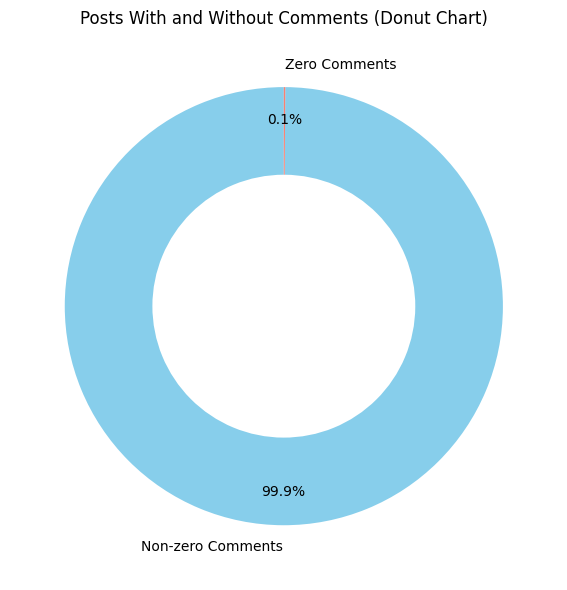

In [14]:
summary = df_beyondblue['num_comments'].eq(0).value_counts()
summary.index = ['Non-zero Comments', 'Zero Comments']

plt.figure(figsize=(6, 6))
summary.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon'],  # match Reddit colors
    startangle=90,
    wedgeprops=dict(width=0.4),  # makes donut
    pctdistance=0.85             # move % text inside ring
)
plt.ylabel('')
plt.title("Posts With and Without Comments (Donut Chart)")
plt.tight_layout()
plt.show()


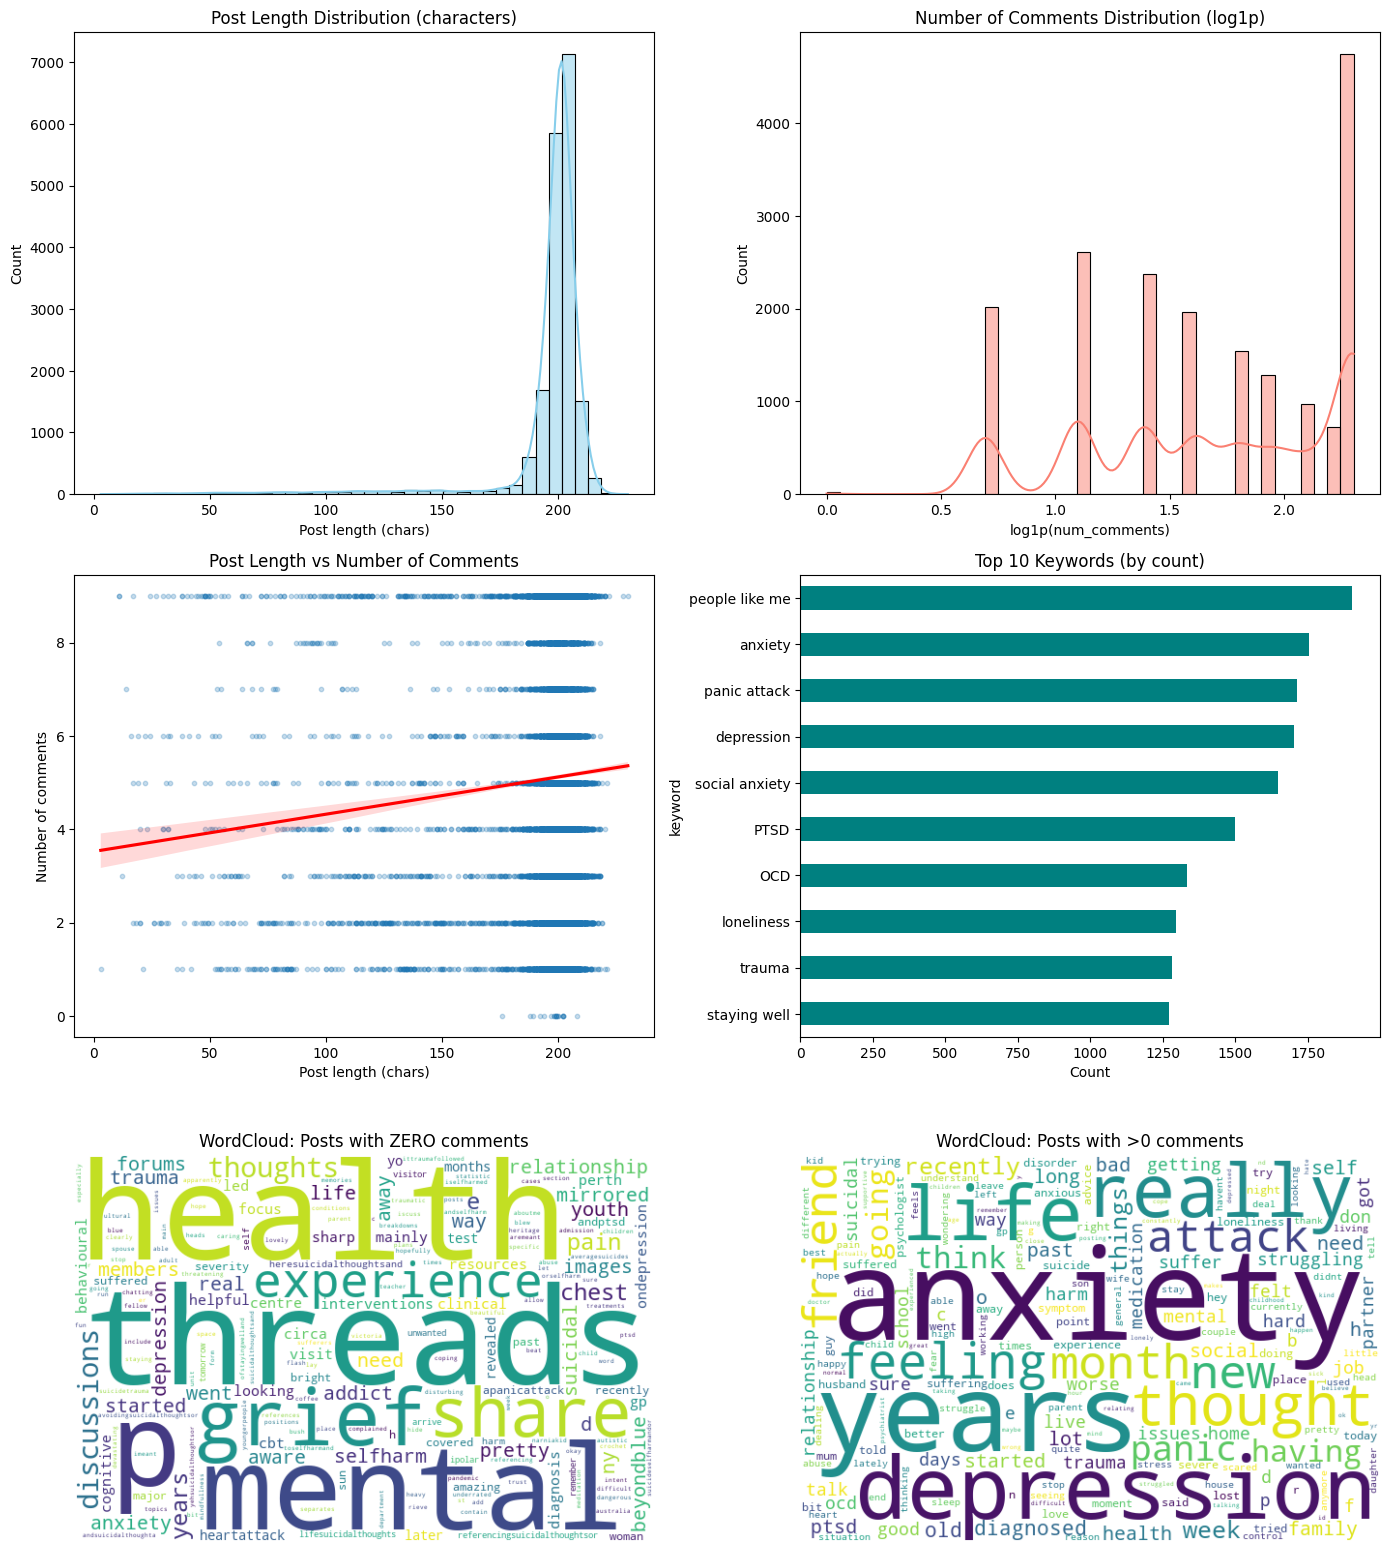

In [16]:
# Visualization cell: multiple views (lengths, comments, keywords, wordclouds)
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

# 1) Post length distribution (chars)
sns.histplot(df_beyondblue['post_length'], bins=40, kde=True, color='skyblue', ax=ax1)
ax1.set_title("Post Length Distribution (characters)")
ax1.set_xlabel("Post length (chars)")

# 2) Number of comments (log1p) distribution to reduce skew
sns.histplot(np.log1p(df_beyondblue['num_comments']), bins=40, kde=True, color='salmon', ax=ax2)
ax2.set_title("Number of Comments Distribution (log1p)")
ax2.set_xlabel("log1p(num_comments)")

# 3) Scatter + regression: post length vs num_comments
sns.regplot(x='post_length', y='num_comments', data=df_beyondblue,
            scatter_kws={'alpha':0.25, 's':10}, line_kws={'color':'red'}, ax=ax3)
ax3.set_title("Post Length vs Number of Comments")
ax3.set_xlabel("Post length (chars)")
ax3.set_ylabel("Number of comments")

# 4) Top 10 keywords (categories)
top_keywords = df_beyondblue['keyword'].value_counts().head(10).iloc[::-1]
top_keywords.plot(kind='barh', ax=ax4, color='teal')
ax4.set_title("Top 10 Keywords (by count)")
ax4.set_xlabel("Count")

# 5 & 6) WordClouds: posts with zero comments vs posts with >0 comments
text_zero = " ".join(df_beyondblue.loc[df_beyondblue['num_comments'] == 0, 'post_content_preview_clean'].astype(str).tolist())
text_nonzero = " ".join(df_beyondblue.loc[df_beyondblue['num_comments'] > 0, 'post_content_preview_clean'].astype(str).tolist())

wc_params = dict(width=600, height=400, background_color='white', stopwords=combined_stopwords, collocations=False)

wc0 = WordCloud(**wc_params).generate(text_zero if text_zero.strip() else " ")
wc1 = WordCloud(**wc_params).generate(text_nonzero if text_nonzero.strip() else " ")

ax5.imshow(wc0, interpolation='bilinear')
ax5.axis('off')
ax5.set_title("WordCloud: Posts with ZERO comments")

ax6.imshow(wc1, interpolation='bilinear')
ax6.axis('off')
ax6.set_title("WordCloud: Posts with >0 comments")

plt.tight_layout()
plt.show()

In [15]:
#covert the current dataaframe to a csv file
df_beyondblue.to_csv("beyondblue_cleaned.csv", index=False)